# Temperature Dependence of $I_c$ and $\Delta$

This notebook loads the voltage/current sweeps in `Leonard/Tdependence`, extracts the Josephson critical current and the superconducting gap from the three-step structure, and compares the reduced quantities to BCS theory.

The raw files contain two tab-separated columns: measured voltage in volts and measured current in amperes.

,temperature_K,file,Ic_A,Delta_meV,gap_voltage_V
0,4.191,4p191K.txt,0.000162,1.447492,0.002895
1,4.510,4p510K.txt,0.000159,1.406366,0.002813
2,5.002,5p002V.txt,0.000158,1.399723,0.002799
3,5.512,5p512K.txt,0.000119,1.027435,0.002055
4,6.068,6p068K.txt,0.000150,1.287857,0.002576
5,6.564,6p564K.txt,0.000142,1.202306,0.002405
6,7.041,7p041K.txt,0.000135,1.107440,0.002215
7,7.439,7p439K.txt,0.000172,1.318422,0.002637
8,7.660,T_7p66K.txt,0.000110,0.877022,0.001754
9,8.160,T_8p16K.txt,0.000124,0.987974,0.001976


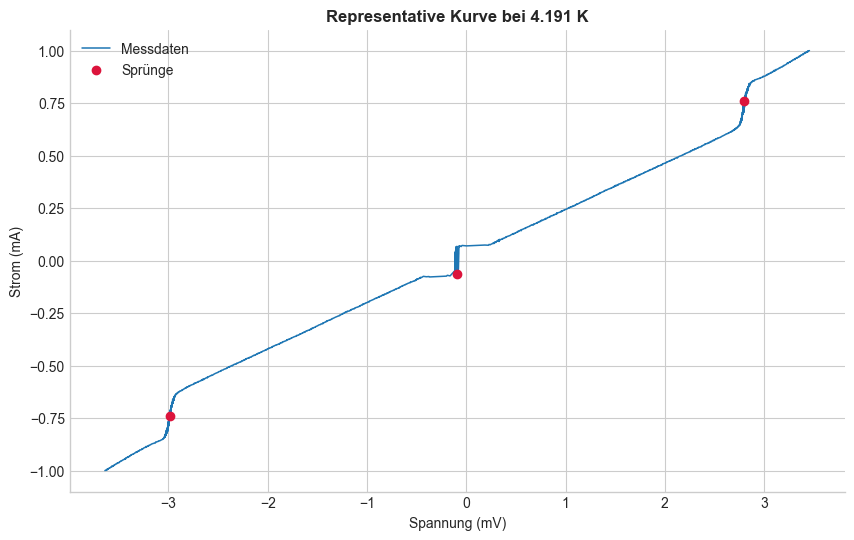

In [8]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
    }
)

K_B = 8.617333262145e-5
E_CHARGE = 1.602176634e-19


def find_data_dir() -> Path:
    candidates = [Path.cwd() / "Tdependence", Path.cwd() / "Leonard" / "Tdependence"]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Could not locate the Tdependence directory.")


def parse_temperature(path: Path) -> float:
    stem = path.stem.replace("T_", "")
    stem = stem.replace("p", ".")
    stem = re.sub(r"[^0-9.]+$", "", stem)
    return float(stem)


def load_curve(path: Path) -> pd.DataFrame:
    frame = pd.read_csv(
        path,
        sep=r"\s+",
        header=None,
        usecols=[0, 1],
        names=["voltage", "current"],
        engine="python",
    )
    frame = frame.apply(pd.to_numeric, errors="coerce").dropna()
    frame = frame.groupby("voltage", as_index=False)["current"].mean().sort_values("voltage").reset_index(drop=True)
    return frame


def smooth_series(values: np.ndarray) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    n_points = len(values)
    if n_points < 7:
        return values
    window_length = max(11, (n_points // 30) | 1)
    if window_length >= n_points:
        window_length = n_points - 1 if n_points % 2 == 0 else n_points
    if window_length < 5:
        return values
    if window_length % 2 == 0:
        window_length -= 1
    polyorder = min(3, window_length - 2)
    return savgol_filter(values, window_length=window_length, polyorder=polyorder)


def region_peak_index(mask: np.ndarray, metric: np.ndarray) -> int | None:
    if mask.sum() == 0:
        return None
    local_indices = np.where(mask)[0]
    return int(local_indices[np.nanargmax(metric[local_indices])])


def detect_steps(frame: pd.DataFrame) -> dict:
    voltage = frame["voltage"].to_numpy()
    current = frame["current"].to_numpy()
    current_smooth = smooth_series(current)
    derivative = np.gradient(current_smooth, voltage)
    abs_derivative = np.abs(derivative)

    voltage_min = float(np.nanmin(voltage))
    voltage_max = float(np.nanmax(voltage))
    voltage_span = voltage_max - voltage_min
    center_guess = float(np.nanmedian(voltage))
    half_width = 0.18 * voltage_span

    left_mask = voltage < center_guess - half_width
    center_mask = np.abs(voltage - center_guess) <= half_width
    right_mask = voltage > center_guess + half_width

    peak_indices = [
        region_peak_index(left_mask, abs_derivative),
        region_peak_index(center_mask, abs_derivative),
        region_peak_index(right_mask, abs_derivative),
    ]
    peak_indices = [idx for idx in peak_indices if idx is not None]

    if len(peak_indices) < 3:
        fallback = np.argsort(abs_derivative)[-12:]
        peak_indices = list(np.unique(fallback))

    peak_indices = np.array(sorted(set(peak_indices), key=lambda idx: voltage[idx]))

    central_peak = peak_indices[np.argmin(np.abs(voltage[peak_indices]))]
    side_peaks = np.array([idx for idx in peak_indices if idx != central_peak])
    if len(side_peaks) < 2:
        left_candidates = np.where(voltage < voltage[central_peak])[0]
        right_candidates = np.where(voltage > voltage[central_peak])[0]
        left_peak = int(left_candidates[np.nanargmax(abs_derivative[left_candidates])]) if len(left_candidates) else central_peak
        right_peak = int(right_candidates[np.nanargmax(abs_derivative[right_candidates])]) if len(right_candidates) else central_peak
    else:
        side_peaks = side_peaks[np.argsort(voltage[side_peaks])]
        left_peak, right_peak = int(side_peaks[0]), int(side_peaks[-1])

    left_window_center = 0.5 * (voltage[left_peak] + voltage[central_peak])
    right_window_center = 0.5 * (voltage[central_peak] + voltage[right_peak])

    left_mask = (voltage >= left_window_center) & (voltage < voltage[central_peak])
    right_mask = (voltage > voltage[central_peak]) & (voltage <= right_window_center)
    if left_mask.sum() < 5:
        left_mask = voltage < voltage[central_peak]
    if right_mask.sum() < 5:
        right_mask = voltage > voltage[central_peak]

    left_branch = np.median(current[left_mask])
    right_branch = np.median(current[right_mask])
    ic = 0.5 * abs(right_branch - left_branch)

    gap_voltage = 0.5 * (abs(voltage[left_peak]) + abs(voltage[right_peak]))
    gap_meV = 500.0 * gap_voltage

    return {
        "voltage": voltage,
        "current": current,
        "current_smooth": current_smooth,
        "derivative": derivative,
        "peak_indices": np.array([left_peak, central_peak, right_peak]),
        "ic_A": ic,
        "gap_voltage_V": gap_voltage,
        "gap_meV": gap_meV,
    }


def bcs_gap_reduced(t: np.ndarray) -> np.ndarray:
    t = np.asarray(t, dtype=float)
    reduced = np.zeros_like(t)
    mask = t < 1
    safe_t = np.clip(t[mask], 1e-9, None)
    reduced[mask] = np.tanh(1.74 * np.sqrt(1.0 / safe_t - 1.0))
    return reduced


def ic_reduced_bcs(t: np.ndarray) -> np.ndarray:
    t = np.asarray(t, dtype=float)
    reduced_gap = bcs_gap_reduced(t)
    reduced = np.zeros_like(t)
    mask = t < 1
    safe_t = np.clip(t[mask], 1e-9, None)
    reduced[mask] = reduced_gap[mask] * np.tanh(0.882 * reduced_gap[mask] / safe_t)
    return reduced


def ic_model(T: np.ndarray, I0: float, Tc: float) -> np.ndarray:
    t = np.clip(np.asarray(T, dtype=float) / Tc, 1e-9, 0.999999)
    return I0 * ic_reduced_bcs(t)


def gap_model(T: np.ndarray, gap0: float, Tc: float) -> np.ndarray:
    t = np.clip(np.asarray(T, dtype=float) / Tc, 1e-9, 0.999999)
    return gap0 * bcs_gap_reduced(t)


def fit_model(temperature: np.ndarray, values: np.ndarray, model, p0, bounds):
    popt, pcov = curve_fit(model, temperature, values, p0=p0, bounds=bounds, maxfev=20000)
    perr = np.sqrt(np.diag(pcov))
    return popt, perr


data_dir = find_data_dir()
curve_files = sorted(data_dir.glob("*.txt"), key=parse_temperature)
records = []
curve_diagnostics = {}

for path in curve_files:
    temperature = parse_temperature(path)
    curve = load_curve(path)
    diagnostics = detect_steps(curve)
    curve_diagnostics[temperature] = diagnostics
    records.append(
        {
            "temperature_K": temperature,
            "file": path.name,
            "Ic_A": diagnostics["ic_A"],
            "Delta_meV": diagnostics["gap_meV"],
            "gap_voltage_V": diagnostics["gap_voltage_V"],
        }
    )

results = pd.DataFrame(records).sort_values("temperature_K").reset_index(drop=True)
display(results)

example_temperature = results.loc[0, "temperature_K"]
example_curve = curve_diagnostics[example_temperature]

fig, ax = plt.subplots()
ax.plot(example_curve["voltage"] * 1e3, example_curve["current"] * 1e3, lw=1.1, label="Messdaten")
peak_indices = example_curve["peak_indices"]
ax.scatter(
    example_curve["voltage"][peak_indices] * 1e3,
    example_curve["current"][peak_indices] * 1e3,
    color="crimson",
    zorder=3,
    label="Sprünge",
)
ax.set_xlabel("Spannung (mV)")
ax.set_ylabel("Strom (mA)")
ax.set_title(f"Representative Kurve bei {example_temperature:.3f} K")
ax.legend()
plt.savefig("Plots/example_curve.pdf", dpi=300, bbox_inches="tight")
plt.show()

,quantity,scale,scale_err,Tc_fit_K,Tc_fit_err_K
0,Ic,0.000156,0.000011,14.999997,2.630848
1,Delta,1.390755,0.078057,10.465577,0.831328


Reference Tc = 9.2 K
Ic fit:    I0 = 1.5630e-04 A, Tc = 15.000 K
Delta fit: D0 = 1.3908 meV, Tc = 10.466 K


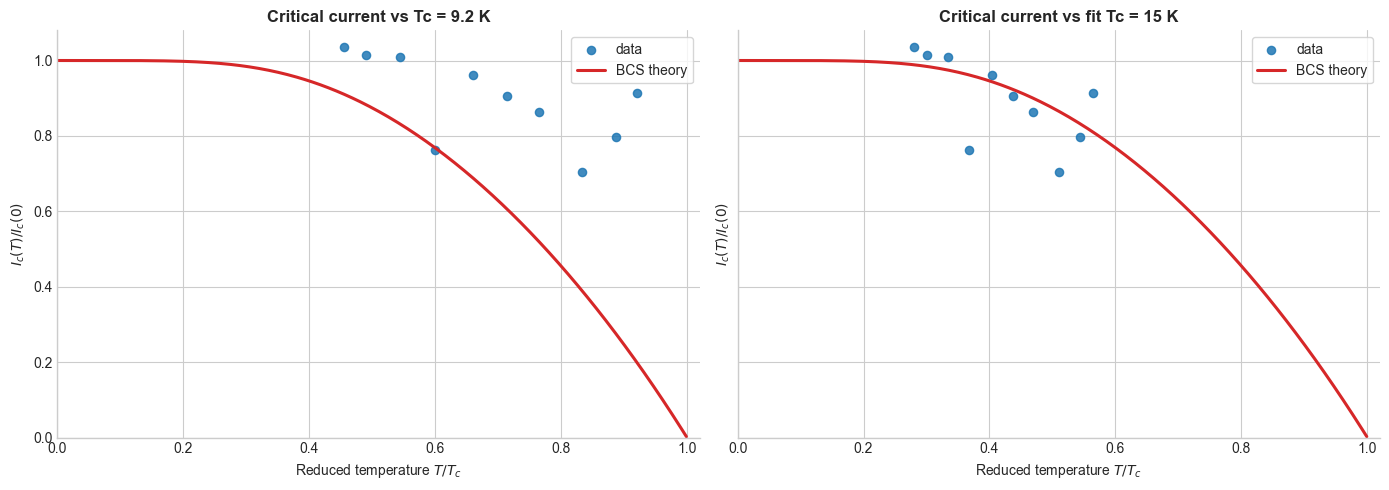

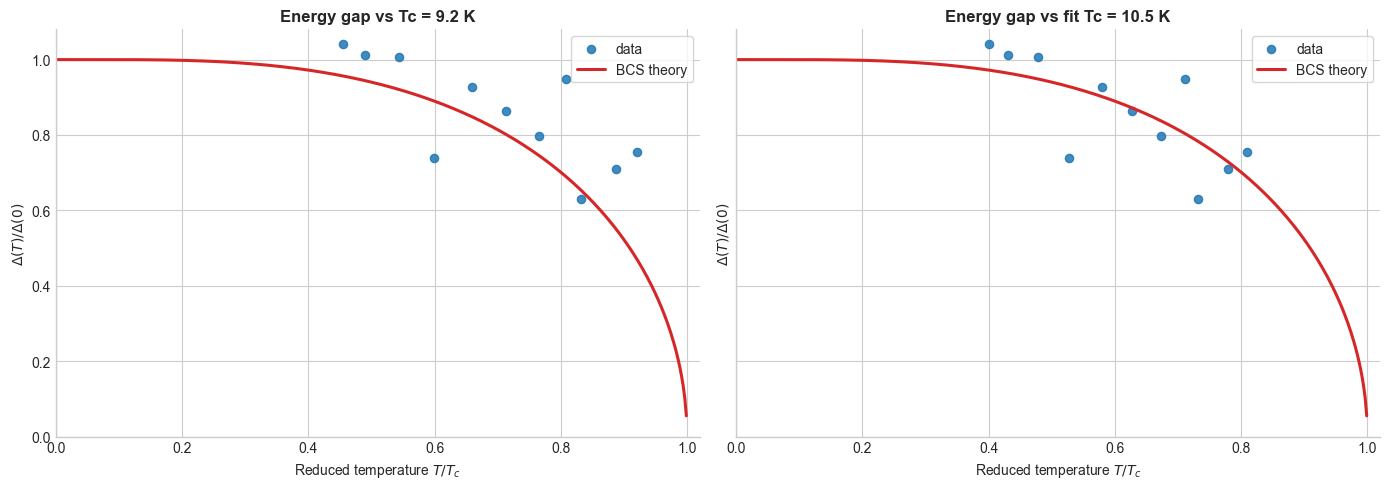

In [16]:
temperature = results["temperature_K"].to_numpy()
ic_values = results["Ic_A"].to_numpy()
gap_values = results["Delta_meV"].to_numpy()

ic_fit, ic_err = fit_model(
    temperature,
    ic_values,
    ic_model,
    p0=[ic_values.max(), 9.2],
    bounds=([0.0, 6.0], [np.inf, 15.0]),
)
gap_fit, gap_err = fit_model(
    temperature,
    gap_values,
    gap_model,
    p0=[gap_values.max(), 9.2],
    bounds=([0.0, 6.0], [np.inf, 15.0]),
)

fit_table = pd.DataFrame(
    [
        {
            "quantity": "Ic",
            "scale": ic_fit[0],
            "scale_err": ic_err[0],
            "Tc_fit_K": ic_fit[1],
            "Tc_fit_err_K": ic_err[1],
        },
        {
            "quantity": "Delta",
            "scale": gap_fit[0],
            "scale_err": gap_err[0],
            "Tc_fit_K": gap_fit[1],
            "Tc_fit_err_K": gap_err[1],
        },
    ]
)

display(fit_table)
print(f"Reference Tc = 9.2 K")
print(f"Ic fit:    I0 = {ic_fit[0]:.4e} A, Tc = {ic_fit[1]:.3f} K")
print(f"Delta fit: D0 = {gap_fit[0]:.4f} meV, Tc = {gap_fit[1]:.3f} K")

results = results.copy()
results["Ic_reduced"] = results["Ic_A"] / ic_fit[0]
results["Delta_reduced"] = results["Delta_meV"] / gap_fit[0]

reduced_grid = np.linspace(0.0, 0.999, 400)
tc_values = [(9.2, "Tc = 9.2 K"), (None, "fit Tc = 15 K")]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (tc_reference, label) in zip(axes, tc_values):
    tc_value = tc_reference if tc_reference is not None else ic_fit[1]
    t_data = temperature / tc_value
    ax.scatter(t_data, results["Ic_reduced"], color="#1f77b4", s=35, alpha=0.85, label="data")
    ax.plot(reduced_grid, ic_reduced_bcs(reduced_grid), color="#d62728", lw=2.2, label="BCS theory")
    ax.set_xlim(0.0, 1.02)
    ax.set_ylim(0.0, 1.08)
    ax.set_xlabel(r"Reduced temperature $T / T_c$")
    ax.set_ylabel(r"$I_c(T) / I_c(0)$")
    ax.set_title(f"Critical current vs {label}")
    ax.legend(frameon=True)

plt.savefig(f"Plots/Ic.pdf", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

tc_values = [(9.2, "Tc = 9.2 K"), (None, "fit Tc = 10.5 K")]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (tc_reference, label) in zip(axes, tc_values):
    tc_value = tc_reference if tc_reference is not None else gap_fit[1]
    t_data = temperature / tc_value
    ax.scatter(t_data, results["Delta_reduced"], color="#1f77b4", s=35, alpha=0.85, label="data")
    ax.plot(reduced_grid, bcs_gap_reduced(reduced_grid), color="#d62728", lw=2.2, label="BCS theory")
    ax.set_xlim(0.0, 1.02)
    ax.set_ylim(0.0, 1.08)
    ax.set_xlabel(r"Reduced temperature $T / T_c$")
    ax.set_ylabel(r"$\Delta(T) / \Delta(0)$")
    ax.set_title(f"Energy gap vs {label}")
    ax.legend(frameon=True)

plt.savefig(f"Plots/Delta.pdf", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()
